# Prédiction du niveau d'éducation parentale

Trois analyses de régression logistique sur student-por :
1. **Medu binaire** : mère faible (0–2) vs élevée (3–4) — avec Fedu comme feature
2. **Fedu binaire** : père faible (0–2) vs élevé (3–4) — avec Medu comme feature
3. **Medu 4 niveaux** : primaire/aucun (0–1), collège (2), lycée (3), supérieur (4)


## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv('../donnees/student-mat.csv')
student_por = pd.read_csv('../donnees/student-por.csv')
student_mat = student_por  # analyse sur le dataset portugais
print(f'Dataset : {student_mat.shape[0]} élèves, {student_mat.shape[1]} variables')


Dataset : 649 élèves, 33 variables


## 2. Construction de la variable cible

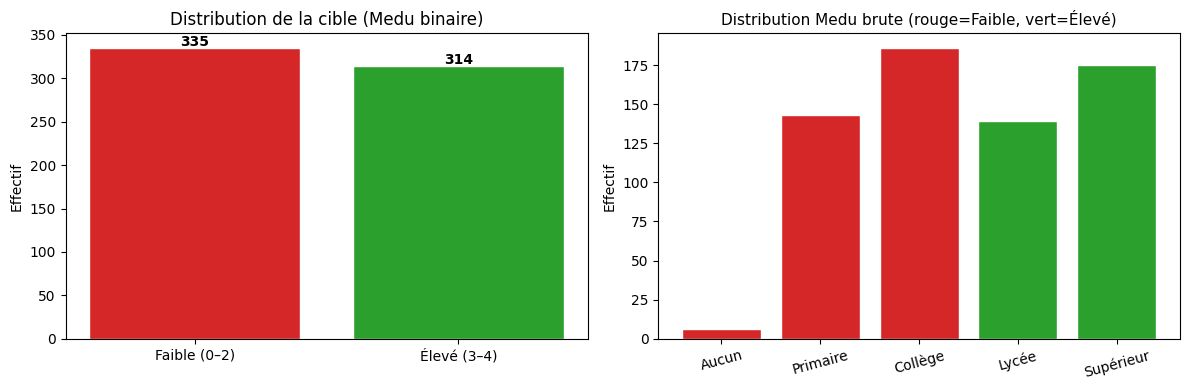

Distribution de la cible :
  Faible (0–2) : 335 élèves (51.6%)
  Élevé (3–4) : 314 élèves (48.4%)
Baseline (classe majoritaire) : 0.516


In [2]:
# Cible binaire : Medu faible (0–2) vs élevée (3–4)
student_mat['medu_target'] = (student_mat['Medu'] >= 3).astype(int)
CLASS_NAMES = {0: 'Faible (0–2)', 1: 'Élevé (3–4)'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des 2 classes
vc = student_mat['medu_target'].value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i] for i in vc.index], vc.values,
            color=['#d62728', '#2ca02c'], edgecolor='white')
axes[0].set_title('Distribution de la cible (Medu binaire)', fontsize=12)
axes[0].set_ylabel('Effectif')
for j, (idx, v) in enumerate(vc.items()):
    axes[0].text(j, v + 2, str(v), ha='center', fontweight='bold')

# Distribution Medu brute
edu_labels = {0:'Aucun', 1:'Primaire', 2:'Collège', 3:'Lycée', 4:'Supérieur'}
vc_raw = student_mat['Medu'].value_counts().sort_index()
colors_raw = ['#d62728']*3 + ['#2ca02c']*2
axes[1].bar([edu_labels[i] for i in vc_raw.index], vc_raw.values,
            color=colors_raw, edgecolor='white')
axes[1].set_title('Distribution Medu brute (rouge=Faible, vert=Élevé)', fontsize=11)
axes[1].set_ylabel('Effectif')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('Distribution de la cible :')
for c, n in vc.items():
    print(f'  {CLASS_NAMES[c]} : {n} élèves ({100*n/len(student_mat):.1f}%)')
print(f'Baseline (classe majoritaire) : {vc.max()/len(student_mat):.3f}')


## 3. Préparation des features

In [3]:
# Fedu inclus comme feature (corrélé à Medu mais pas la cible)
num_cols  = ['age','Fedu','traveltime','studytime','failures','famrel','freetime',
             'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_cols = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_cols  = ['school','sex','address','famsize','Pstatus','reason','guardian']

def prepare_X(df):
    bool_df = df[bool_cols].apply(lambda c: (c == 'yes').astype(int)).reset_index(drop=True)
    enc     = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_arr = enc.fit_transform(df[cat_cols])
    cat_df  = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_cols))
    return pd.concat([df[num_cols].reset_index(drop=True), bool_df, cat_df], axis=1)

X = prepare_X(student_mat)
y = student_mat['medu_target'].values
print(f'Features : {X.shape[1]} variables ({len(num_cols)} num dont Fedu, {len(bool_cols)} bool, {len(cat_cols)} cat→OHE)')
print(f'Individus : {len(y)}')


Features : 33 variables (15 num dont Fedu, 8 bool, 7 cat→OHE)
Individus : 649


## 4. Régression logistique binaire

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cv5 = cross_val_score(pipe, X, y,
                      cv=StratifiedKFold(5, shuffle=True, random_state=42),
                      scoring='accuracy')

print(f'Accuracy test : {acc:.3f} ({acc*100:.1f}%)')
print(f'CV-5          : {cv5.mean():.3f} ± {cv5.std():.3f}')
print(f'Baseline (maj): {max(y.mean(), 1-y.mean()):.3f}')
print()
print(classification_report(y_test, y_pred,
      target_names=[CLASS_NAMES[0], CLASS_NAMES[1]]))


Accuracy test : 0.755 (75.5%)
CV-5          : 0.767 ± 0.033
Baseline (maj): 0.516

              precision    recall  f1-score   support

Faible (0–2)       0.74      0.80      0.77        84
 Élevé (3–4)       0.77      0.71      0.74        79

    accuracy                           0.75       163
   macro avg       0.76      0.75      0.75       163
weighted avg       0.76      0.75      0.75       163



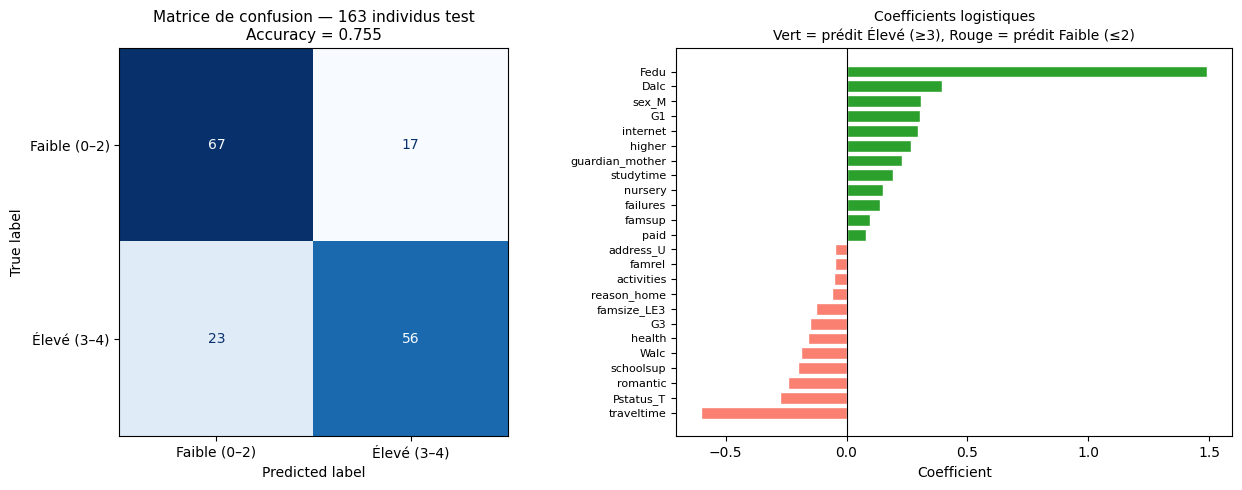

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de confusion — {len(y_test)} individus test\nAccuracy = {acc:.3f}', fontsize=11)

# Coefficients
coef = pipe.named_steps['clf'].coef_[0]
feat_names = list(X.columns)
idx_sorted = np.argsort(coef)
top_idx = np.concatenate([idx_sorted[:12], idx_sorted[-12:]])
vals  = coef[top_idx]
names = [feat_names[i] for i in top_idx]
colors = ['salmon' if v < 0 else '#2ca02c' for v in vals]
axes[1].barh(range(len(vals)), vals, color=colors, edgecolor='white')
axes[1].set_yticks(range(len(vals)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients logistiques\nVert = prédit Élevé (≥3), Rouge = prédit Faible (≤2)', fontsize=10)
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()


---
## 5. Fedu binaire — éducation du père

Même approche que pour Medu. **Medu** devient une feature (corrélée à Fedu).
Fedu ≤ 2 → Faible (390 élèves) | Fedu ≥ 3 → Élevé (259 élèves).


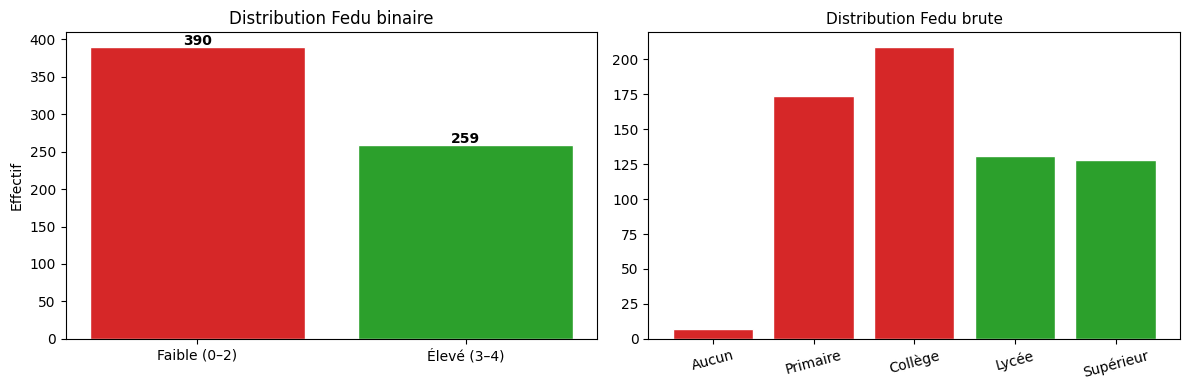

Distribution Fedu binaire :
  Faible (0–2) : 390 élèves (60.1%)
  Élevé (3–4) : 259 élèves (39.9%)
Baseline : 0.601


In [8]:
# Cible : Fedu binaire
student_mat['fedu_target'] = (student_mat['Fedu'] >= 3).astype(int)
FNAMES = {0: 'Faible (0–2)', 1: 'Élevé (3–4)'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc_f = student_mat['fedu_target'].value_counts().sort_index()
axes[0].bar([FNAMES[i] for i in vc_f.index], vc_f.values,
            color=['#d62728','#2ca02c'], edgecolor='white')
axes[0].set_title('Distribution Fedu binaire', fontsize=12)
axes[0].set_ylabel('Effectif')
for j, (idx, v) in enumerate(vc_f.items()):
    axes[0].text(j, v+2, str(v), ha='center', fontweight='bold')

edu_labels = {0:'Aucun',1:'Primaire',2:'Collège',3:'Lycée',4:'Supérieur'}
vc_raw = student_mat['Fedu'].value_counts().sort_index()
axes[1].bar([edu_labels[i] for i in vc_raw.index], vc_raw.values,
            color=['#d62728']*3+['#2ca02c']*2, edgecolor='white')
axes[1].set_title('Distribution Fedu brute', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print('Distribution Fedu binaire :')
for c, n in vc_f.items():
    print(f'  {FNAMES[c]} : {n} élèves ({100*n/len(student_mat):.1f}%)')
print(f'Baseline : {vc_f.max()/len(student_mat):.3f}')


In [9]:
# Features pour Fedu : Medu inclus, Fedu exclu
num_fedu  = ['age','Medu','traveltime','studytime','failures','famrel','freetime',
             'goout','Dalc','Walc','health','absences','G1','G2','G3']
bool_cols = ['schoolsup','famsup','paid','activities','higher','nursery','internet','romantic']
cat_cols  = ['school','sex','address','famsize','Pstatus','reason','guardian']

def prepare_X_fedu(df):
    bool_df = df[bool_cols].apply(lambda c: (c=='yes').astype(int)).reset_index(drop=True)
    enc     = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    cat_arr = enc.fit_transform(df[cat_cols])
    cat_df  = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(cat_cols))
    return pd.concat([df[num_fedu].reset_index(drop=True), bool_df, cat_df], axis=1)

X_f = prepare_X_fedu(student_mat)
y_f = student_mat['fedu_target'].values

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.25, random_state=42, stratify=y_f)
pipe_f = Pipeline([('scaler', StandardScaler()),
                   ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_f.fit(Xf_tr, yf_tr)
yf_pred = pipe_f.predict(Xf_te)

acc_f = accuracy_score(yf_te, yf_pred)
cv5_f = cross_val_score(pipe_f, X_f, y_f, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f'Accuracy test : {acc_f:.3f} ({acc_f*100:.1f}%)')
print(f'CV-5          : {cv5_f.mean():.3f} ± {cv5_f.std():.3f}')
print(f'Baseline      : {vc_f.max()/len(student_mat):.3f}')
print()
print(classification_report(yf_te, yf_pred, target_names=[FNAMES[0], FNAMES[1]]))


Accuracy test : 0.730 (73.0%)
CV-5          : 0.773 ± 0.025
Baseline      : 0.601

              precision    recall  f1-score   support

Faible (0–2)       0.79      0.76      0.77        98
 Élevé (3–4)       0.65      0.69      0.67        65

    accuracy                           0.73       163
   macro avg       0.72      0.72      0.72       163
weighted avg       0.73      0.73      0.73       163



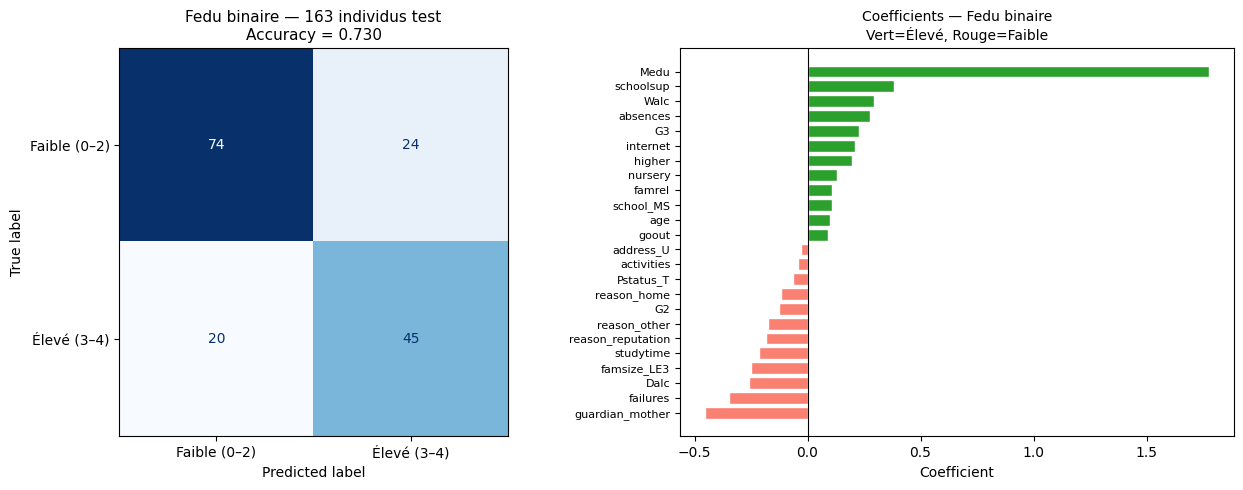

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_f = confusion_matrix(yf_te, yf_pred)
ConfusionMatrixDisplay(cm_f, display_labels=[FNAMES[0], FNAMES[1]]).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Fedu binaire — {len(yf_te)} individus test\nAccuracy = {acc_f:.3f}', fontsize=11)

coef_f = pipe_f.named_steps['clf'].coef_[0]
fn_f   = list(X_f.columns)
idx_f  = np.argsort(coef_f)
top_f  = np.concatenate([idx_f[:12], idx_f[-12:]])
vals_f = coef_f[top_f]
axes[1].barh(range(len(vals_f)), vals_f,
             color=['salmon' if v<0 else '#2ca02c' for v in vals_f], edgecolor='white')
axes[1].set_yticks(range(len(vals_f)))
axes[1].set_yticklabels([fn_f[i] for i in top_f], fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Coefficients — Fedu binaire\nVert=Élevé, Rouge=Faible', fontsize=10)
axes[1].set_xlabel('Coefficient')
plt.tight_layout(); plt.show()


---
## 6. Medu — 4 niveaux (1–2–3–4)

On fusionne les niveaux 0 et 1 (seulement 6 élèves au niveau 0) pour obtenir
4 classes : **Primaire** (0–1), **Collège** (2), **Lycée** (3), **Supérieur** (4).
Distribution : 149 / 186 / 139 / 175 — assez équilibrée.


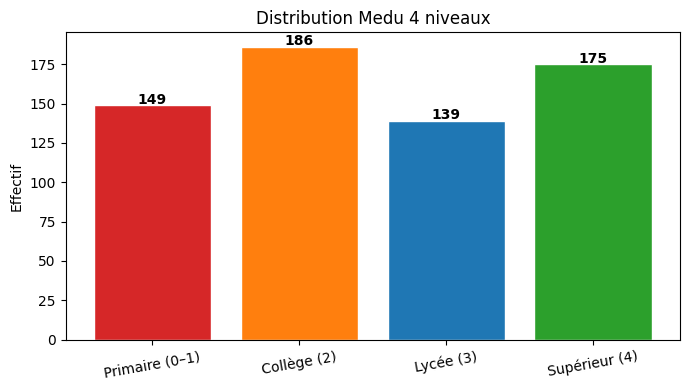

Distribution : {1: 149, 2: 186, 3: 139, 4: 175}
Baseline (classe maj) : 0.287


In [10]:
# Cible : Medu 4 niveaux (fusion 0→1)
student_mat['medu4_target'] = student_mat['Medu'].clip(lower=1)
M4_NAMES = {1:'Primaire (0–1)', 2:'Collège (2)', 3:'Lycée (3)', 4:'Supérieur (4)'}

vc_m4 = student_mat['medu4_target'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([M4_NAMES[i] for i in vc_m4.index], vc_m4.values,
       color=['#d62728','#ff7f0e','#1f77b4','#2ca02c'], edgecolor='white')
ax.set_title('Distribution Medu 4 niveaux', fontsize=12)
ax.set_ylabel('Effectif')
ax.tick_params(axis='x', rotation=10)
for j, (idx, v) in enumerate(vc_m4.items()):
    ax.text(j, v+1, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

print('Distribution :', vc_m4.to_dict())
print(f'Baseline (classe maj) : {vc_m4.max()/len(student_mat):.3f}')


In [11]:
# Régression logistique multiclasse — Medu 4 niveaux
# Même features que section 3 (Fedu inclus)
X_m4 = prepare_X(student_mat)   # fonction définie en section 3
y_m4 = student_mat['medu4_target'].values

Xm4_tr, Xm4_te, ym4_tr, ym4_te = train_test_split(X_m4, y_m4, test_size=0.25, random_state=42, stratify=y_m4)
pipe_m4 = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42))])
pipe_m4.fit(Xm4_tr, ym4_tr)
ym4_pred = pipe_m4.predict(Xm4_te)

acc_m4 = accuracy_score(ym4_te, ym4_pred)
cv5_m4 = cross_val_score(pipe_m4, X_m4, y_m4, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print(f'Accuracy test : {acc_m4:.3f} ({acc_m4*100:.1f}%)')
print(f'CV-5          : {cv5_m4.mean():.3f} ± {cv5_m4.std():.3f}')
print(f'Baseline      : {vc_m4.max()/len(student_mat):.3f}')
print()
lbs = sorted(set(ym4_te)|set(ym4_pred))
print(classification_report(ym4_te, ym4_pred,
      labels=lbs, target_names=[M4_NAMES[l] for l in lbs]))


Accuracy test : 0.448 (44.8%)
CV-5          : 0.496 ± 0.018
Baseline      : 0.287

                precision    recall  f1-score   support

Primaire (0–1)       0.45      0.41      0.43        37
   Collège (2)       0.36      0.40      0.38        47
     Lycée (3)       0.26      0.17      0.21        35
 Supérieur (4)       0.61      0.75      0.67        44

      accuracy                           0.45       163
     macro avg       0.42      0.43      0.42       163
  weighted avg       0.43      0.45      0.43       163



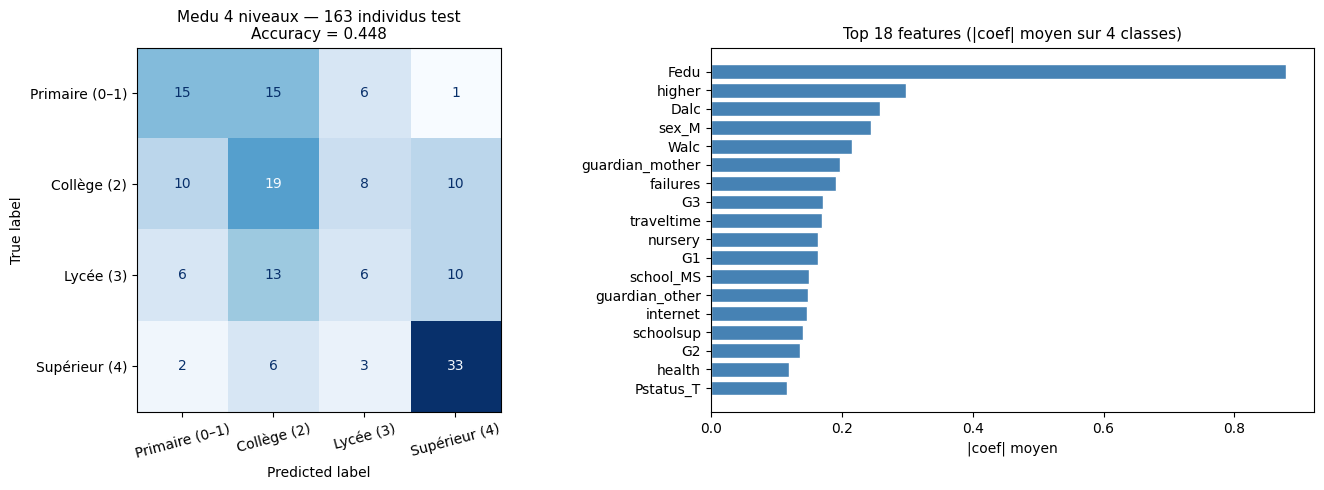

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
lbs_all = sorted(set(y_m4))
cm_m4 = confusion_matrix(ym4_te, ym4_pred, labels=lbs_all)
ConfusionMatrixDisplay(cm_m4, display_labels=[M4_NAMES[l] for l in lbs_all]).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Medu 4 niveaux — {len(ym4_te)} individus test\nAccuracy = {acc_m4:.3f}', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Coefficients (|coef| moyen sur les 4 classes)
coefs_m4   = pipe_m4.named_steps['clf'].coef_
mean_abs_m4 = np.abs(coefs_m4).mean(axis=0)
fn_m4      = list(X_m4.columns)
top_m4     = np.argsort(mean_abs_m4)[::-1][:18]
axes[1].barh([fn_m4[i] for i in top_m4][::-1],
             mean_abs_m4[top_m4][::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 18 features (|coef| moyen sur 4 classes)', fontsize=11)
axes[1].set_xlabel('|coef| moyen')
plt.tight_layout(); plt.show()


---
## 7. Récapitulatif

| Analyse | Classes | N | Baseline | CV-5 | +? |
|---------|---------|---|----------|------|------|
| Medu binaire | Faible vs Élevé | 649 | 51.6% | 76.7% |+21,1%|
| Fedu binaire | Faible vs Élevé | 649 | 60.1% | 77.3% |12.2%|
| Medu 4 niveaux | Primaire/Collège/Lycée/Supérieur | 649 | 28.7% | 49.6% |20.9%|

La prédiction binaire est plus robuste ; le passage à 4 classes augmente la difficulté
mais permet une analyse plus fine des frontières entre niveaux d'éducation.
